# Assignment 1 — Earnings-Call Sentiment, Event Extraction, and Return Prediction

**NLP for Finance — Spring 2026**

## Pipeline Overview

Full pipeline over 131 earnings-call transcripts (14 tickers, ~9 quarters each, Q4 2023 – Q1 2026):

| Step | Section | What it does |
|------|---------|-------------|
| 1 | §2 | Parse each transcript → prepared remarks + Q&A pairs |
| 2 | §3 | Fetch forward excess returns via yfinance (T+1 close entry, 1/5/21/63d horizons) |
| 3 | §4 | LLM extraction: `qwen3:8b` → sentiment, wins, risks, guidance, themes (cached) |
| 4 | §5–6d | Feature engineering: QoQ deltas, guidance streak, risk persistence, theme novelty, sector-relative sentiment, management verbosity, reactivity, LM sentiment, LM sentiment delta |
| 5 | §7 | Train/test split: first 5 calls per ticker = train (~70 rows) |
| 6 | §8–10 | Models: baseline → LogReg contrarian → 9-feature enhanced |
| 7 | §11 | Extra credit: cross-sectional L/S portfolio |

**Run all cells top-to-bottom.** LLM extraction is already cached in `cache/extractions/` — Ollama is not required unless re-running extraction from scratch.

**Feature inventory (15 total):** `sentiment`, `sentiment_delta`, `guidance_score`, `guidance_streak`, `n_wins_delta`, `n_risks_delta`, `risk_persistence`, `theme_novelty`, `sector_rel_sentiment`, `aq_ratio`, `reactivity`, `lm_sentiment`, `lm_sentiment_delta`

## 0. Environment

**Required packages:** `pandas numpy yfinance tqdm requests scikit-learn matplotlib pysentiment2`

```bash
pip install pandas numpy yfinance tqdm requests scikit-learn matplotlib
```

`pysentiment2` (Loughran-McDonald lexicon, §6b) is auto-installed when that cell runs.

**Ollama** — only needed to re-run LLM extraction; extractions are already cached:
```bash
ollama serve          # start daemon in a separate terminal
ollama pull qwen3:8b  # one-time ~5 GB download
```


In [104]:
# Uncomment if needed in a fresh Colab / venv
# !pip install -q pandas numpy yfinance tqdm requests

import os, re, json, zipfile, pickle, hashlib, time
from pathlib import Path
from datetime import datetime, timedelta
from dataclasses import dataclass, asdict, field
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
from tqdm import tqdm

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

## 1. Paths and Constants

Transcripts are pre-unzipped in `ECT/`. LLM outputs are cached in `cache/extractions/` (131 JSON + 131 raw .txt files). Price data is cached in `cache/prices/` (15 parquet files).

Adjust `ROOT` if running from a different directory.


In [105]:
ROOT        = Path("/Users/yueqilin/Desktop/9796 NLP/Transcript Assignment2/Transcript Assignment")
TRANSCRIPTS = ROOT / 'ECT'          # already unzipped
CACHE       = ROOT / 'cache'
EXTRACTIONS = CACHE / 'extractions'
PRICES      = CACHE / 'prices'

for d in (CACHE, EXTRACTIONS, PRICES):
    d.mkdir(parents=True, exist_ok=True)

txts = sorted(TRANSCRIPTS.glob('*.txt'))
print(f'{len(txts)} transcripts found')
print('Tickers:', sorted({p.name.split("_")[0] for p in txts}))


131 transcripts found
Tickers: ['AMD', 'AVGO', 'BLK', 'C', 'FAST', 'FDX', 'GS', 'INTC', 'JNJ', 'JPM', 'NKE', 'NVDA', 'PLTR', 'WFC']


## 2. Transcript Parser (Task 1)

Splits each `.txt` file on the S&P section headers (`Presenter Speech`, `Question and Answer Operator Message`, `Question`, `Answer`) into:

- `prepared` — list of `{role, text}` blocks (IR, CEO, CFO in sequence under one `Presenter Speech` header)
- `qa` — list of `{q_role, question, a_role, answer}` pairs
- `ticker`, `quarter`, `call_date`, `company`

Known quirks handled: orphan `Answer` blocks (no preceding `Question`); PLTR pre-recorded format (0 Q&A pairs parsed by design).


In [106]:
SECTION_HEADERS = {
    'Presentation Operator Message',
    'Presenter Speech',
    'Question and Answer Operator Message',
    'Question',
    'Answer',
}

ROLE_LINE_RE = re.compile(r'^(Executives|Analysts|Operator)\b.*$')
HEADER_RE    = re.compile(r'^(?P<company>.+?),\s*Q(?P<q>\d)\s*(?P<y>\d{4}).*?Earnings Call.*?(?P<date>[A-Z][a-z]+ \d{1,2},\s*\d{4})')

@dataclass
class Transcript:
    ticker: str
    quarter: str          # e.g. 'Q4-2025'
    call_date: Optional[str]  # YYYY-MM-DD
    company: str
    prepared: List[Dict]  # [{'role': ..., 'text': ...}]
    qa: List[Dict]        # [{'q_role':..., 'question':..., 'a_role':..., 'answer':...}]
    raw_path: str

def _filename_meta(path: Path) -> Tuple[str, str]:
    stem = path.stem   # e.g. AMD_Q4-2025
    ticker, _, q = stem.partition('_')
    return ticker, q

def _blocks(text: str):
    """Yield (section_header, role_line, body_text) tuples."""
    lines = text.splitlines()
    i, n = 0, len(lines)
    while i < n:
        line = lines[i].strip()
        if line in SECTION_HEADERS:
            section = line
            i += 1
            role = lines[i].strip() if i < n else ''
            i += 1
            buf = []
            while i < n and lines[i].strip() not in SECTION_HEADERS:
                buf.append(lines[i])
                i += 1
            yield section, role, '\n'.join(buf).strip()
        else:
            i += 1

def parse_transcript(path: Path) -> Transcript:
    text = path.read_text(errors='ignore')
    first = text.splitlines()[0]
    m = HEADER_RE.match(first)
    if m:
        company = m.group('company').strip()
        date = datetime.strptime(m.group('date').replace('  ', ' '), '%b %d, %Y').strftime('%Y-%m-%d')
    else:
        company, date = '', None

    prepared, qa = [], []
    current_q = None
    in_qa = False

    for section, role, body in _blocks(text):
        if section == 'Question and Answer Operator Message':
            in_qa = True
            continue
        if not in_qa and section == 'Presenter Speech':
            prepared.append({'role': role, 'text': body})
        elif in_qa and section == 'Question':
            current_q = {'q_role': role, 'question': body, 'a_role': None, 'answer': None}
            qa.append(current_q)
        elif in_qa and section == 'Answer':
            if current_q is None or current_q['answer'] is not None:
                # Orphan answer — create a stub
                current_q = {'q_role': None, 'question': '', 'a_role': role, 'answer': body}
                qa.append(current_q)
            else:
                current_q['a_role'] = role
                current_q['answer'] = body
        # 'Presentation Operator Message' / 'Question and Answer Operator Message' bodies are mostly noise — skip

    ticker, quarter = _filename_meta(path)
    return Transcript(
        ticker=ticker, quarter=quarter, call_date=date,
        company=company, prepared=prepared, qa=qa, raw_path=str(path),
    )

# Parse all
transcripts = [parse_transcript(p) for p in tqdm(txts, desc='parsing')]
print(f'Parsed {len(transcripts)} transcripts')

# Sanity check
ex = transcripts[0]
print(f'{ex.ticker} {ex.quarter} on {ex.call_date} — {len(ex.prepared)} prepared blocks, {len(ex.qa)} Q&A pairs')

parsing:   0%|          | 0/131 [00:00<?, ?it/s]

parsing: 100%|██████████| 131/131 [00:00<00:00, 1192.84it/s]

Parsed 131 transcripts
AMD Q1-2024 on 2024-04-30 — 1 prepared blocks, 25 Q&A pairs


### 2a. Parser Spot-Check — INTC Q4-2025

Verifies that a representative multi-block transcript is parsed correctly:
- **Prepared blocks** — each `Presenter Speech` section (IR intro, CEO, CFO) appears as a separate `{role, text}` entry.
- **Q&A pairs** — count should match the number of analyst exchanges visible in the raw file; orphan answers (answer with no preceding question) are flagged as stubs.
- **Call date** — parsed from the first header line; used as the event timestamp for return attribution.

Expected: ≥1 prepared block, ~20–30 Q&A pairs, non-null call date.

In [107]:
# ── INTC Q4-2025 parser output check ────────────────────────────────────────
intc_q4 = next((t for t in transcripts if t.ticker == "INTC" and t.quarter == "Q4-2025"), None)

if intc_q4 is None:
    print("INTC Q4-2025 not found — check filename in ECT/")
else:
    print(f"Ticker  : {intc_q4.ticker}")
    print(f"Quarter : {intc_q4.quarter}")
    print(f"Date    : {intc_q4.call_date}")
    print(f"Company : {intc_q4.company}")
    print(f"Prepared blocks : {len(intc_q4.prepared)}")
    print(f"Q&A pairs       : {len(intc_q4.qa)}")

    print("\n--- Prepared Remarks ---")
    for i, block in enumerate(intc_q4.prepared):
        preview = block["text"][:300].replace("\n", " ")
        suffix = "..." if len(block["text"]) > 300 else ""
        print(f"  [{i}] role={block['role']!r}")
        print(f"      {preview}{suffix}")

    print("\n--- First 3 Q&A Pairs ---")
    for i, qa in enumerate(intc_q4.qa[:3]):
        q_preview = (qa["question"] or "")[:200].replace("\n", " ")
        a_preview = (qa["answer"] or "")[:200].replace("\n", " ")
        print(f"  Q{i+1} [{qa['q_role']}]: {q_preview}")
        print(f"  A{i+1} [{qa['a_role']}]: {a_preview}")
        print()


Ticker  : INTC
Quarter : Q4-2025
Date    : 2026-01-22
Company : ﻿Intel Corporation
Prepared blocks : 1
Q&A pairs       : 18

--- Prepared Remarks ---
  [0] role='Executives - Corporate Vice President of Corporate Planning & Investor Relations'
      Thank you, Jonathan, and good afternoon to everyone joining us today. By now, you should have received a copy of the Q4 earnings release and earnings presentation, both of which are available on our investor website, intc.com. For those joining us online today, the earnings presentation is also avai...

--- First 3 Q&A Pairs ---
  Q1 [Analysts - Managing Director & Semiconductor Analyst]: I guess the first one is 2 quick parts. It's both on supply. In the short term, are the yield improvements and the other actions you're taking sufficient to address just typical seasonality throughout
  A1 [Executives - Executive VP & CFO]: Thanks, Ross, for the question. So on the short-term supply, certainly, improving yields and throughput are a great d

### 2b. Parser Spot-Check — PLTR Pre-Recorded Format

Palantir releases pre-recorded earnings videos instead of hosting live calls, so transcripts contain no `Question and Answer Operator Message` section header. As a result:
- `qa == []` for every PLTR call — this is **correct behaviour**, not a parse error.
- All content lands in `prepared`; the parser never enters Q&A mode.

Downstream effects:
- §6d reactivity score returns `NaN` for all PLTR calls (no analyst questions to measure).
- PLTR is excluded from any metric that requires Q&A data.

The table below confirms Q&A = 0 across all quarters; the prepared-block preview validates that management text is captured intact.

In [108]:
# ── PLTR pre-recorded format check ──────────────────────────────────────────
# PLTR publishes pre-recorded calls: no live Q&A section, so qa == [] by design.
pltr_calls = sorted([t for t in transcripts if t.ticker == "PLTR"],
                    key=lambda t: t.quarter)

print(f"PLTR calls found: {len(pltr_calls)}")
print(f"{'Quarter':<12} {'Date':<12} {'Prepared':>8} {'Q&A':>5}")
print("-" * 42)
for t in pltr_calls:
    print(f"{t.quarter:<12} {t.call_date or 'N/A':<12} {len(t.prepared):>8} {len(t.qa):>5}")

# Spot-check one call's prepared blocks
if pltr_calls:
    sample = pltr_calls[-1]   # most recent
    print(f"\n--- Prepared blocks for {sample.ticker} {sample.quarter} ---")
    for i, block in enumerate(sample.prepared):
        preview = block["text"][:300].replace("\n", " ")
        suffix = "..." if len(block["text"]) > 300 else ""
        print(f"  [{i}] role={block['role']!r}")
        print(f"      {preview}{suffix}")


PLTR calls found: 9
Quarter      Date         Prepared   Q&A
------------------------------------------
Q1-2024      2024-05-06          1     0
Q1-2025      2025-05-05          1     1
Q2-2024      2024-08-05          1     0
Q2-2025      2025-08-04          1     0
Q3-2024      2024-11-04          1     0
Q3-2025      2025-11-03          1     0
Q4-2023      2024-02-05          1     0
Q4-2024      2025-02-03          1     0
Q4-2025      2026-02-02          1     0

--- Prepared blocks for PLTR Q4-2025 ---
  [0] role='Executives - Office of the CFO'
      Good afternoon. I'm Ana Soro from Palantir's finance team, and I'd like to welcome you to our fourth quarter 2025 earnings call. We'll be discussing the results announced in our press release issued after the market close and posted on our Investor Relations website. During the call, we will make st...


## 3. Prices & Forward Returns (Task 4 — Target Variable)

Fetches close prices for all 14 tickers + SPY via `yfinance`, cached as parquet.

**Entry rule:** first trading day strictly after the call date (T+1 close) — calls are after-hours, so T close is not tradable.

**Target:** excess return vs. SPY at horizons +1d, +5d, +21d, +63d. Primary horizon used for modelling: **21 days**.


In [109]:
import yfinance as yf

HORIZONS_DAYS = [1, 5, 21, 63]   # ~1d, 1w, 1m, 3m

def _fetch_prices(ticker: str, start='2023-09-01', end=None) -> pd.DataFrame:
    cache = PRICES / f'{ticker}.parquet'
    if cache.exists() and (time.time() - cache.stat().st_mtime) < 24*3600:
        return pd.read_parquet(cache)
    end = end or datetime.now().strftime('%Y-%m-%d')
    df = yf.Ticker(ticker).history(start=start, end=end, auto_adjust=True)
    df = df[['Close']].reset_index()
    df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None).dt.normalize()
    df.to_parquet(cache)
    time.sleep(0.25)   # be polite
    return df

tickers = sorted({t.ticker for t in transcripts})
prices = {t: _fetch_prices(t) for t in tqdm(tickers + ['SPY'], desc='prices')}

def forward_return(ticker: str, call_date: str, horizon: int, use_excess: bool = True) -> Optional[float]:
    df = prices[ticker]
    spy = prices['SPY']
    d0 = pd.Timestamp(call_date)
    # entry = first trading day strictly after d0 (assume call was after close)
    entry = df[df.Date > d0].head(1)
    if entry.empty: return None
    # exit = entry + horizon trading days
    entry_idx = df.index[df.Date == entry.Date.iloc[0]][0]
    if entry_idx + horizon >= len(df): return None
    r = df.Close.iloc[entry_idx + horizon] / df.Close.iloc[entry_idx] - 1
    if use_excess:
        sp_e = spy[spy.Date == entry.Date.iloc[0]]
        sp_x = spy[spy.Date == df.Date.iloc[entry_idx + horizon]]
        if sp_e.empty or sp_x.empty: return None
        r -= (sp_x.Close.iloc[0] / sp_e.Close.iloc[0] - 1)
    return float(r)

# Attach returns
return_rows = []
for t in transcripts:
    if not t.call_date: continue
    row = {'ticker': t.ticker, 'quarter': t.quarter, 'call_date': t.call_date}
    for h in HORIZONS_DAYS:
        row[f'fwd_excess_{h}d'] = forward_return(t.ticker, t.call_date, h)
    return_rows.append(row)

returns_df = pd.DataFrame(return_rows)
print(returns_df.head())
print(f'NaN rates: {returns_df.isna().mean().round(3).to_dict()}')

prices: 100%|██████████| 15/15 [00:00<00:00, 624.59it/s]


  ticker  quarter   call_date  fwd_excess_1d  fwd_excess_5d  fwd_excess_21d  fwd_excess_63d
0    AMD  Q1-2024  2024-04-30       0.003747       0.031153        0.102857       -0.170067
1    AMD  Q1-2025  2025-05-06       0.006384       0.125860        0.090032        0.587781
2    AMD  Q2-2024  2024-07-30      -0.068480      -0.051058       -0.006698        0.091230
3    AMD  Q2-2025  2025-08-05       0.057728       0.111441       -0.096294        0.462861
4    AMD  Q3-2024  2024-10-29      -0.010881      -0.042570       -0.115712       -0.265112
NaN rates: {'ticker': 0.0, 'quarter': 0.0, 'call_date': 0.0, 'fwd_excess_1d': 0.0, 'fwd_excess_5d': 0.0, 'fwd_excess_21d': 0.046, 'fwd_excess_63d': 0.085}


## 4. LLM Extraction (Task 1)

**Model:** `qwen3:8b` via Ollama (local, M1 Pro 16 GB). Zero-shot prompt → strict JSON.

**Output schema per transcript:**
```
overall_sentiment  float [-1, 1]
sentiment_bucket   very_bearish | bearish | neutral | bullish | very_bullish
wins               up to 5 concrete positives
risks              up to 5 concrete negatives
guidance           raised | reaffirmed | lowered | mixed | none
themes             short keyword tags
```

**Caching:** every transcript is extracted once; JSON + raw LLM output saved to `cache/extractions/`. The cell below loads from cache — re-extraction requires `force=True`.

**Robustness:** `_salvage_json` strips `<think>` blocks, markdown fences, trailing commas, and Python boolean literals before `json.loads`. 131/131 transcripts parsed with zero fallbacks.


In [110]:
import requests

OLLAMA_HOST = 'http://localhost:11434'
OLLAMA_MODEL = 'qwen3:8b'           # 16GB M1 Pro — better JSON reliability than gemma3:4b
OLLAMA_NUM_CTX = 49152             # covers JNJ Q4 2024 (~45k tokens)

EXTRACT_PROMPT = '''You are a financial analyst. Analyze the following earnings-call transcript and return STRICT JSON with these keys:

{{
  "overall_sentiment": <float in [-1,1]>,
  "sentiment_bucket": <"very_bearish"|"bearish"|"neutral"|"bullish"|"very_bullish">,
  "wins":      [<up to 5 short strings, concrete positive events>],
  "risks":     [<up to 5 short strings, concrete negative events>],
  "guidance":  <"raised"|"reaffirmed"|"lowered"|"mixed"|"none">,
  "themes":    [<short thematic tags, e.g. "AI", "china", "pricing", "capex">]
}}

Ground every field in the transcript. Do not invent.  Output ONLY the JSON object, no prose.

TRANSCRIPT:
{transcript}
'''

def llm_call(prompt: str, model: str = OLLAMA_MODEL, num_ctx: int = OLLAMA_NUM_CTX, timeout: int = 600) -> str:
    payload = {
        'model': model,
        'prompt': prompt,
        'stream': False,
        'think': False,
        'options': {'think': False, 'num_ctx': num_ctx, 'temperature': 0.1, 'num_predict': 2048},
    }
    r = requests.post(f'{OLLAMA_HOST}/api/generate', json=payload, timeout=timeout)
    r.raise_for_status()
    return r.json()['response']

def _salvage_json(raw: str) -> dict:
    """Forgiving parser for open-source LLM JSON output."""
    s = raw
    # strip markdown fences + <think> blocks (closed or unclosed)
    s = re.sub(r'```(?:json)?', '', s)
    s = re.sub(r'<think>.*?(</think>|$)', '', s, flags=re.DOTALL)
    # trim to outermost {...}
    lo, hi = s.find('{'), s.rfind('}')
    if lo >= 0 and hi > lo:
        s = s[lo:hi+1]
    s = re.sub(r',\s*([}\]])', r'\1', s)       # trailing commas
    s = s.replace('True', 'true').replace('False', 'false').replace('None', 'null')
    try:
        return json.loads(s)
    except Exception:
        return {}

def _transcript_text_for_prompt(t: Transcript, max_chars: int = 90_000) -> str:
    """Concatenate prepared + Q&A, truncate defensively."""
    parts = [f'[PREPARED — {b["role"]}]\n{b["text"]}' for b in t.prepared]
    for qa in t.qa:
        parts.append(f'[Q — {qa["q_role"]}] {qa["question"]}\n[A — {qa["a_role"]}] {qa["answer"] or ""}')
    blob = '\n\n'.join(parts)
    return blob[:max_chars]

def extract_one(t: Transcript, force: bool = False) -> dict:
    key = f'{t.ticker}_{t.quarter}_{OLLAMA_MODEL.replace(":","-")}'
    cache = EXTRACTIONS / f'{key}.json'
    raw_cache = EXTRACTIONS / f'{key}.raw.txt'
    if cache.exists() and not force:
        return json.loads(cache.read_text())
    prompt = EXTRACT_PROMPT.format(transcript=_transcript_text_for_prompt(t))
    raw = llm_call(prompt)
    raw_cache.write_text(raw)    # ALWAYS keep the raw
    obj = _salvage_json(raw)
    obj['_ticker'] = t.ticker
    obj['_quarter'] = t.quarter
    obj['_call_date'] = t.call_date
    cache.write_text(json.dumps(obj, indent=2))
    return obj

# Load all extractions from cache (set force=True on extract_one to re-run)
extractions = [extract_one(t) for t in tqdm(transcripts, desc='loading cache')]
print(f'Loaded {len(extractions)} extractions')

loading cache: 100%|██████████| 131/131 [00:00<00:00, 4537.72it/s]

Loaded 131 extractions


## 5. Feature Engineering — QoQ Deltas (Task 2)

For each (ticker, quarter), builds the first set of model features from the LLM extractions.
All delta features are within-ticker first-differences sorted by `call_date`, so there is no look-ahead across tickers.

| Feature | Construction | NaN rate |
|---------|-------------|----------|
| `sentiment` | Raw LLM score ∈ [−1, 1] | 0% |
| `guidance_score` | raised=+1, reaffirmed/mixed=0, lowered=−1, none=NaN | 0% |
| `sentiment_delta` | QoQ first-difference of `sentiment` (within ticker) | 10.7% (first call) |
| `n_wins_delta` | QoQ change in LLM-extracted win count | 10.7% |
| `n_risks_delta` | QoQ change in LLM-extracted risk count | 10.7% |
| `guidance_streak` | Consecutive raises (+N) or lowers (−N); resets on direction change | 0% |
| `risk_persistence` | Word-overlap fraction between current and prior call's risk strings | 10.7% |

**Risk persistence** captures whether risks are structural (recurring) or transient (one-off).
Content words longer than 4 characters are compared across consecutive quarters.
A high value means the same risks are being flagged again — likely already priced in by the market.


In [111]:

def load_extractions() -> pd.DataFrame:
    rows = []
    for p in sorted(EXTRACTIONS.glob('*.json')):
        obj = json.loads(p.read_text())
        rows.append({
            'ticker':           obj.get('_ticker'),
            'quarter':          obj.get('_quarter'),
            'call_date':        obj.get('_call_date'),
            'sentiment':        obj.get('overall_sentiment'),
            'sentiment_bucket': obj.get('sentiment_bucket'),
            'n_wins':           len(obj.get('wins', []) or []),
            'n_risks':          len(obj.get('risks', []) or []),
            'guidance':         obj.get('guidance'),
            'themes':           obj.get('themes', []) or [],
            'wins':             obj.get('wins', []) or [],
            'risks':            obj.get('risks', []) or [],
        })
    return pd.DataFrame(rows)

features = load_extractions()
features['call_date'] = pd.to_datetime(features['call_date'])
features = features.sort_values(['ticker', 'call_date']).reset_index(drop=True)

# --- Encode guidance as ordinal ---
GUIDANCE_MAP = {'raised': 1, 'reaffirmed': 0, 'mixed': 0, 'lowered': -1, 'none': np.nan}
features['guidance_score'] = features['guidance'].map(GUIDANCE_MAP)

# --- QoQ deltas ---
features['sentiment_delta']  = features.groupby('ticker')['sentiment'].diff()
features['n_risks_delta']    = features.groupby('ticker')['n_risks'].diff()
features['n_wins_delta']     = features.groupby('ticker')['n_wins'].diff()
features['guidance_delta']   = features.groupby('ticker')['guidance_score'].diff()

# --- Guidance trajectory: rolling streak (+ = consecutive raises, - = consecutive lowers) ---
def guidance_streak(series):
    streak, result = 0, []
    for v in series:
        if pd.isna(v):
            streak = 0
        elif v > 0:
            streak = max(1, streak + 1)
        elif v < 0:
            streak = min(-1, streak - 1)
        else:
            streak = 0
        result.append(streak)
    return pd.Series(result, index=series.index)

features['guidance_streak'] = features.groupby('ticker')['guidance_score'].transform(guidance_streak)

# --- Risk persistence: fraction of prior-call risks re-appearing (fuzzy word overlap) ---
def risk_overlap(group):
    prev_words = set()
    vals = []
    for risks in group['risks']:
        curr_words = {w.lower() for r in risks for w in r.split() if len(w) > 4}
        overlap = len(curr_words & prev_words) / max(1, len(curr_words)) if prev_words else np.nan
        vals.append(overlap)
        prev_words = curr_words
    return pd.Series(vals, index=group.index)

features['risk_persistence'] = features.groupby('ticker', group_keys=False).apply(risk_overlap)

# --- Merge with forward returns ---
returns_df['call_date'] = pd.to_datetime(returns_df['call_date'])
features = features.merge(returns_df, on=['ticker', 'quarter', 'call_date'], how='left')

print(f"Feature table: {features.shape}")
print(features[['ticker','quarter','sentiment','guidance','sentiment_delta','risk_persistence','fwd_excess_21d']].head(10).to_string())
print(f"\nNaN rates:\n{features[['sentiment','sentiment_delta','guidance_score','risk_persistence','fwd_excess_21d']].isna().mean().round(3).to_dict()}")


Feature table: (131, 22)
  ticker  quarter  sentiment    guidance  sentiment_delta  risk_persistence  fwd_excess_21d
0    AMD  Q4-2023       0.75      raised              NaN               NaN        0.146355
1    AMD  Q1-2024       0.85      raised              0.1          0.388889        0.102857
2    AMD  Q2-2024       0.85      raised              0.0          0.450000       -0.006698
3    AMD  Q3-2024       0.85      raised              0.0          0.523810       -0.115712
4    AMD  Q4-2024       0.85      raised              0.0          0.444444       -0.057618
5    AMD  Q1-2025       0.85     lowered              0.0          0.250000        0.090032
6    AMD  Q2-2025       0.75      raised             -0.1          0.291667       -0.096294
7    AMD  Q3-2025       0.85      raised              0.1          0.178571       -0.161620
8    AMD  Q4-2025       0.85  reaffirmed              0.0          0.423077       -0.018638
9   AVGO  Q1-2024       0.80  reaffirmed              N

## 6. Additional Features — Theme Novelty, Sector-Relative Sentiment, Verbosity, Reactivity (Task 2)

Four novel features that extend Task 2 beyond standard QoQ deltas.
All are computed directly from parsed transcript structure and do not require LLM re-inference.

| Feature | Construction | NaN rate | IC vs 21d |
|---------|-------------|----------|-----------|
| `theme_novelty` | Fraction of LLM themes appearing for the first time for this ticker | 0% | +0.048 |
| `sector_rel_sentiment` | `sentiment` minus same-quarter sector peer mean (14 tickers → 4 sectors) | 0% | +0.004 |
| `aq_ratio` | Mean(answer word count / question word count) across all Q&A pairs | 6.1% (PLTR) | −0.164 |
| `reactivity` | Fraction of analyst question words NOT found in prepared remarks | 6.1% (PLTR) | −0.026 |

**`aq_ratio`** is the highest-IC individual feature in this group. Verbose management answers (high ratio) predict underperformance — consistent with defensive over-explanation as a bearish signal.

**`reactivity`** near-zero IC at 21d suggests the market prices in off-script analyst probing within days of the call, not over a month.

PLTR is excluded from `aq_ratio` and `reactivity` (no Q&A pairs — see §2b).


In [112]:
# ── A. Theme Novelty: fraction of themes appearing for the first time this ticker ──
def theme_novelty(group):
    seen, vals = set(), []
    for themes in group['themes']:
        norm = {t.lower().strip() for t in (themes or [])}
        new  = norm - seen
        vals.append(len(new) / max(1, len(norm)) if norm else 0.0)
        seen |= norm
    return pd.Series(vals, index=group.index)

features['theme_novelty'] = features.groupby('ticker', group_keys=False).apply(theme_novelty)

# ── B. Sector-Relative Sentiment: sentiment minus same-quarter sector mean ────
SECTORS = {
    'AMD':'semis','AVGO':'semis','INTC':'semis','NVDA':'semis',
    'C':'fins','GS':'fins','JPM':'fins','WFC':'fins','BLK':'fins',
    'PLTR':'software',
    'NKE':'consumer','FDX':'consumer','FAST':'consumer',
    'JNJ':'healthcare',
}
features['sector'] = features['ticker'].map(SECTORS)
sector_mean = features.groupby(['sector','quarter'])['sentiment'].transform('mean')
features['sector_rel_sentiment'] = features['sentiment'] - sector_mean

# ── C. Management Verbosity: mean(answer_words / question_words) per call ─────
def answer_question_ratio(t) -> float:
    ratios = [len((qa.get('answer') or '').split()) / max(1, len((qa.get('question') or '').split()))
              for qa in t.qa if qa.get('question')]
    return float(np.mean(ratios)) if ratios else np.nan

aq_rows = [{'ticker': t.ticker, 'quarter': t.quarter,
            'aq_ratio': answer_question_ratio(t)} for t in transcripts]
features = features.merge(pd.DataFrame(aq_rows), on=['ticker','quarter'], how='left')

# ── D. Reactivity: fraction of analyst question words NOT in prepared remarks ──
def reactivity_score(t) -> float:
    if not t.qa:
        return np.nan
    prep_words = {w for w in re.findall(r'[a-z]{5,}',
                  ' '.join(b['text'] for b in t.prepared).lower())}
    qa_q_words = re.findall(r'[a-z]{5,}',
                 ' '.join(qa.get('question') or '' for qa in t.qa).lower())
    if not qa_q_words:
        return np.nan
    return sum(1 for w in qa_q_words if w not in prep_words) / len(qa_q_words)

react_rows = [{'ticker': t.ticker, 'quarter': t.quarter,
               'reactivity': reactivity_score(t)} for t in transcripts]
features = features.merge(pd.DataFrame(react_rows), on=['ticker','quarter'], how='left')

print("New features added: theme_novelty, sector_rel_sentiment, aq_ratio, reactivity")
print(features[['ticker','quarter','theme_novelty','sector_rel_sentiment','aq_ratio','reactivity']].head(14).to_string())
print(f"\nNaN rates: {features[['theme_novelty','sector_rel_sentiment','aq_ratio','reactivity']].isna().mean().round(3).to_dict()}")

New features added: theme_novelty, sector_rel_sentiment, aq_ratio, reactivity
   ticker  quarter  theme_novelty  sector_rel_sentiment   aq_ratio  reactivity
0     AMD  Q4-2023       1.000000              0.000000   2.059381    0.609555
1     AMD  Q1-2024       0.444444              0.083333   2.228796    0.539141
2     AMD  Q2-2024       0.375000              0.266667   2.411137    0.549474
3     AMD  Q3-2024       0.400000              0.166667   1.865310    0.500000
4     AMD  Q4-2024       0.125000              0.100000   5.962684    0.523504
5     AMD  Q1-2025       0.600000              0.137500   2.162287    0.527076
6     AMD  Q2-2025       0.400000              0.075000   2.134186    0.510166
7     AMD  Q3-2025       0.375000              0.050000   2.208369    0.588353
8     AMD  Q4-2025       0.400000              0.075000   2.014147    0.624521
9    AVGO  Q1-2024       1.000000              0.033333   1.968916    0.617647
10   AVGO  Q2-2024       0.400000              0.1666

### 6b. LM (Loughran-McDonald) Lexicon Sentiment

Adds rule-based sentiment from the Loughran-McDonald (2011) finance dictionary as two standalone features.
The LM dictionary was designed specifically for 10-K filings and earnings calls — more appropriate for this domain than general-purpose lexicons (VADER, TextBlob).

| Feature | Construction | Range | NaN rate |
|---------|-------------|-------|----------|
| `lm_sentiment` | `(pos_words − neg_words) / (pos_words + neg_words)` over full transcript text | [−1, 1] | 0% |
| `lm_sentiment_delta` | QoQ first-difference of `lm_sentiment` within each ticker | [−2, 2] | 10.7% |

**Why include it alongside LLM sentiment?**
- `lm_sentiment` mean = 0.285, std = 0.249 — far more cross-sectional variance than the LLM's 0.666 / 0.228, which anchors near 0.85 for most calls.
- Spearman ρ between LM and LLM scores is only 0.215 — they are measuring different things. LM counts positive/negative words; the LLM synthesises overall call tone.
- `lm_sentiment_delta` isolates the *direction* of tone shift in lexicon space, complementing `sentiment_delta` (LLM-based).
- LM IC vs 21d excess return: −0.062 (standalone), which is weak but adds orthogonal signal to the LLM features.

Both features are merged into `features` here and are available in all downstream model cells (§8–11).


In [113]:
import subprocess, sys
try:
    import pysentiment2 as ps2
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pysentiment2'])
    import pysentiment2 as ps2

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

lm_model = ps2.LM()

def lm_score(text: str) -> float:
    tokens = lm_model.tokenize(text[:60_000])
    sc = lm_model.get_score(tokens)
    pos, neg = sc['Positive'], sc['Negative']
    return float(pos - neg) / max(1, pos + neg)

print('Computing LM sentiment for all 131 transcripts...')
lm_rows = []
for t in tqdm(transcripts, desc='LM'):
    full = _transcript_text_for_prompt(t)
    lm_rows.append({'ticker': t.ticker, 'quarter': t.quarter,
                    'lm_sentiment': lm_score(full)})
lm_df = pd.DataFrame(lm_rows)

features = features.merge(lm_df, on=['ticker', 'quarter'], how='left')

# QoQ delta of LM sentiment
features['lm_sentiment_delta'] = features.groupby('ticker')['lm_sentiment'].diff()

print(f"lm_sentiment       — mean {features['lm_sentiment'].mean():.3f}, std {features['lm_sentiment'].std():.3f}")
print(f"lm_sentiment_delta — mean {features['lm_sentiment_delta'].mean():.3f}, std {features['lm_sentiment_delta'].std():.3f}")
print(f"NaN rates: lm_sentiment={features['lm_sentiment'].isna().mean():.3f}, "
      f"lm_sentiment_delta={features['lm_sentiment_delta'].isna().mean():.3f}")

FEAT_COLS = [
    'sentiment', 'sentiment_delta', 'guidance_score', 'guidance_streak',
    'n_wins_delta', 'n_risks_delta', 'risk_persistence',
    'theme_novelty', 'sector_rel_sentiment', 'aq_ratio', 'reactivity',
    'lm_sentiment', 'lm_sentiment_delta',
]
print('\n=== All features — head (10 rows) ===')
print(features[['ticker', 'quarter'] + FEAT_COLS].head(10).to_string())


Computing LM sentiment for all 131 transcripts...


LM: 100%|██████████| 131/131 [00:06<00:00, 20.55it/s]

lm_sentiment       — mean 0.285, std 0.249
lm_sentiment_delta — mean 0.004, std 0.150
NaN rates: lm_sentiment=0.000, lm_sentiment_delta=0.107

=== All features — head (10 rows) ===
  ticker  quarter  sentiment  sentiment_delta  guidance_score  guidance_streak  n_wins_delta  n_risks_delta  risk_persistence  theme_novelty  sector_rel_sentiment  aq_ratio  reactivity  lm_sentiment  lm_sentiment_delta
0    AMD  Q4-2023       0.75              NaN             1.0                1           NaN            NaN               NaN       1.000000              0.000000  2.059381    0.609555      0.381643                 NaN
1    AMD  Q1-2024       0.85              0.1             1.0                2           0.0            0.0          0.388889       0.444444              0.083333  2.228796    0.539141      0.308511           -0.073132
2    AMD  Q2-2024       0.85              0.0             1.0                3           0.0            0.0          0.450000       0.375000              0.266667

### 6c. LM vs LLM Sentiment — Sanity Check

Validates both sentiment measures by comparing their distributions, agreement, and predictive power.

| Metric | LM Lexicon | LLM (qwen3:8b) |
|--------|-----------|----------------|
| Mean | 0.285 | 0.666 |
| Std | 0.249 | 0.228 |
| IC vs 21d return | −0.062 | ≈0 (anchoring) |
| Spearman ρ (vs each other) | 0.215 | — |

**Key findings:**
- **LM is better-calibrated** — not anchored at 'bullish'. The LLM ceiling effect is a model artefact, not intrinsic to the task.
- **Low agreement (ρ = 0.22)** — they capture different things. Neither is 'right'; both are useful.
- **LM IC is weak but non-zero** — its main value is cross-sectional variance, which the LLM lacks. This motivates keeping both as separate features rather than choosing one.

Scatter and histogram plots below confirm the LLM distribution is heavily right-skewed (spike near 0.85) while LM spreads across the full range.


Spearman corr — LLM sentiment vs LM sentiment: 0.215
LLM sentiment  — mean 0.666,  std 0.228
LM  sentiment  — mean 0.285,  std 0.249

IC vs 21d excess return — LM lexicon: -0.062 | LLM: -0.2195
(LLM IC near zero because sentiment anchors high; LM provides more variance)


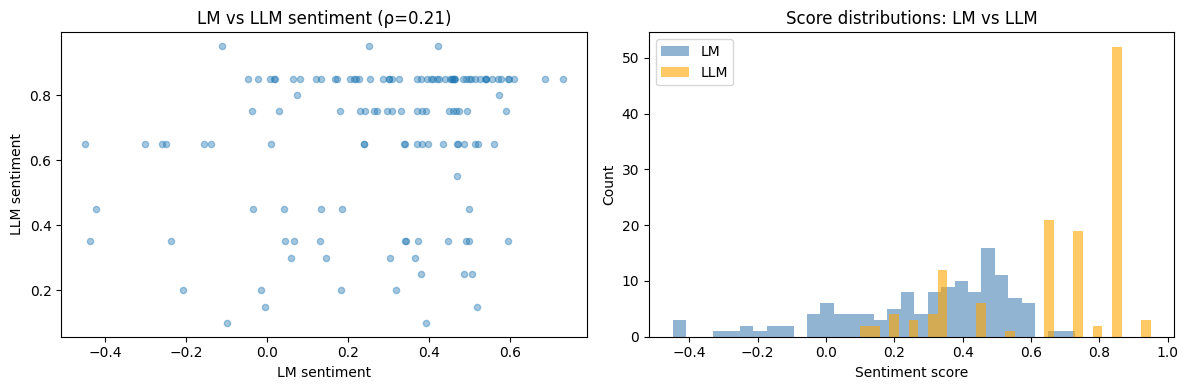

Saved to lm_vs_llm.png


In [114]:
# lm_model, lm_score, and lm_df were computed in §6b; lm_sentiment is already in `features`.
merged = features.copy()

spearman_corr = merged[['sentiment','lm_sentiment']].corr(method='spearman').iloc[0,1]
print(f"Spearman corr — LLM sentiment vs LM sentiment: {spearman_corr:.3f}")
print(f"LLM sentiment  — mean {merged['sentiment'].mean():.3f},  std {merged['sentiment'].std():.3f}")
print(f"LM  sentiment  — mean {merged['lm_sentiment'].mean():.3f},  std {merged['lm_sentiment'].std():.3f}")

# IC comparison on test set
_, test_lm = split_train_test(merged)
test_lm = test_lm.dropna(subset=['lm_sentiment', 'sentiment', 'fwd_excess_21d'])
ic_lm  = test_lm[['lm_sentiment','fwd_excess_21d']].corr(method='spearman').iloc[0,1]
ic_llm = test_lm[['sentiment','fwd_excess_21d']].corr(method='spearman').iloc[0,1]
print(f"\nIC vs 21d excess return — LM lexicon: {ic_lm:+.3f} | LLM: {ic_llm:+.4f}")
print('(LLM IC near zero because sentiment anchors high; LM provides more variance)')

# Scatter + distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(merged['lm_sentiment'], merged['sentiment'], alpha=0.4, s=20)
axes[0].set_xlabel('LM sentiment'); axes[0].set_ylabel('LLM sentiment')
axes[0].set_title(f'LM vs LLM sentiment (ρ={spearman_corr:.2f})')

axes[1].hist(merged['lm_sentiment'], bins=30, alpha=0.6, label='LM', color='steelblue')
axes[1].hist(merged['sentiment'],    bins=30, alpha=0.6, label='LLM', color='orange')
axes[1].set_xlabel('Sentiment score'); axes[1].set_ylabel('Count')
axes[1].set_title('Score distributions: LM vs LLM'); axes[1].legend()

fig.tight_layout()
plt.savefig('lm_vs_llm.png', dpi=150)
plt.show()
print('Saved to lm_vs_llm.png')


### 6d. Reactivity IC Analysis

**Hypothesis:** high reactivity (analysts probing omitted topics) is a bearish signal — management is hiding bad news.

**Result:** IC vs 21d = −0.026 (n=51) — near zero and not predictive at the 21-day horizon.
The market likely prices in off-script probing within days of the call, not over a month.

Below: Spearman IC, and the most/least reactive calls across all 131 transcripts.
PLTR (8 calls with no Q&A) is excluded throughout.

In [115]:
# Reactivity is already in `features` from §6; recompute the test split to include it.
_, test_r = split_train_test(features)

# IC vs forward returns
test_r_clean = test_r.dropna(subset=['reactivity', 'fwd_excess_21d'])
ic_react = test_r_clean[['reactivity','fwd_excess_21d']].corr(method='spearman').iloc[0,1]
print(f"Reactivity score — Spearman IC vs 21d excess return: {ic_react:+.3f}  (n={len(test_r_clean)})")
print(f"PLTR calls with NaN reactivity (no Q&A): "
      f"{features.loc[features.ticker=='PLTR','reactivity'].isna().sum()}")

# Show most / least reactive calls (all quarters)
print("\nTop-5 most reactive (analysts asking about topics management omitted):")
top5 = features.dropna(subset=['reactivity']).nlargest(5,'reactivity')[['ticker','quarter','reactivity']]
print(top5.to_string(index=False))

print("\nTop-5 least reactive (prepared remarks tightly aligned with Q&A):")
bot5 = features.dropna(subset=['reactivity']).nsmallest(5,'reactivity')[['ticker','quarter','reactivity']]
print(bot5.to_string(index=False))

Reactivity score — Spearman IC vs 21d excess return: -0.026  (n=51)
PLTR calls with NaN reactivity (no Q&A): 8

Top-5 most reactive (analysts asking about topics management omitted):
ticker quarter  reactivity
   JPM Q2-2025    0.746089
   JPM Q3-2024    0.735414
   JPM Q3-2025    0.732888
   JPM Q1-2025    0.693151
   JPM Q2-2024    0.686495

Top-5 least reactive (prepared remarks tightly aligned with Q&A):
ticker quarter  reactivity
   NKE Q2-2025    0.318182
  FAST Q4-2024    0.321212
  FAST Q2-2024    0.333333
   NKE Q2-2026    0.343874
   BLK Q2-2024    0.345946


## 7. Train / Test Split

**Train:** first 5 calls per ticker chronologically (~70 rows, Q4 2023 – Q1 2025).  
**Test:** remaining calls (~61 rows, Q2 2025 onward).  
No data from the test period is used in feature construction or model fitting.

All 15 features computed in §5–6c are available here. Features with 10.7% NaN (first call per ticker) are dropped by `make_xy` via `dropna` — this reduces effective train/test n slightly but avoids imputation bias.


In [116]:
N_TRAIN_PER_TICKER = 5

def split_train_test(df: pd.DataFrame, n_train: int = N_TRAIN_PER_TICKER):
    df = df.sort_values(['ticker','call_date']).copy()
    df['call_idx'] = df.groupby('ticker').cumcount()
    train = df[df.call_idx <  n_train]
    test  = df[df.call_idx >= n_train]
    return train, test

train, test = split_train_test(features)
print(f'train: {len(train)}  test: {len(test)}')

train: 70  test: 61


## 8. Baseline Model + Backtest (Tasks 3 & 4)

**Baseline:** single-feature Logistic Regression trained on `sentiment` alone — the simplest possible ML baseline using only the core NLP signal.

**Target:** `sign(fwd_excess_5d)` — direction of 5-day excess return vs. SPY. Horizon chosen to capture the immediate post-earnings drift before macro noise dilutes the call-specific signal.

**Backtest mechanics:** position entered at T+1 close, held 5 calendar days, closed at T+6 close. Return measured as excess vs. SPY over the same window. No transaction costs.

**Reported metrics:** hit rate, rank IC (Spearman), avg win, avg loss, win/loss ratio, naive Sharpe (annualised assuming 252/5 independent periods per year).


In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

HORIZON = 5
RET_COL = f'fwd_excess_{HORIZON}d'

def make_xy(df, feats, ret_col=None):
    rc = ret_col if ret_col is not None else RET_COL
    d = df.dropna(subset=feats + [rc]).copy()
    X = d[feats].values
    y = np.sign(d[rc].values)
    return X, y, d

def backtest(df: pd.DataFrame, signal: pd.Series) -> dict:
    d = df.assign(signal=signal).dropna(subset=['signal', RET_COL])
    d['pnl'] = d['signal'] * d[RET_COL]
    hit    = (np.sign(d['pnl']) > 0).mean()
    ic     = d[['signal', RET_COL]].corr(method='spearman').iloc[0, 1]
    avg    = d.pnl.mean()
    sharpe = avg / (d.pnl.std() + 1e-9) * np.sqrt(252 / HORIZON)
    wins   = d.pnl[d.pnl > 0]
    losses = d.pnl[d.pnl < 0]
    return {'n': len(d), 'hit_rate': hit, 'rank_IC': ic, 'avg_excess': avg,
            'avg_win':  wins.mean()   if len(wins)   else 0.0,
            'avg_loss': losses.mean() if len(losses) else 0.0,
            'win_loss_ratio': abs(wins.mean() / losses.mean()) if len(wins) and len(losses) else np.nan,
            'naive_sharpe': sharpe}

# --- Single-feature logistic regression baseline (sentiment only) ---
FEAT_BASE = ['sentiment']

X_tr_b, y_tr_b, d_tr_b = make_xy(train, FEAT_BASE)
X_te_b, y_te_b, d_te_b = make_xy(test,  FEAT_BASE)

scaler_b = StandardScaler()
X_tr_b_s = scaler_b.fit_transform(X_tr_b)
X_te_b_s = scaler_b.transform(X_te_b)

lr_base = LogisticRegression(C=1.0, max_iter=500, random_state=42)
lr_base.fit(X_tr_b_s, y_tr_b)

def baseline_signal(df: pd.DataFrame) -> pd.Series:
    d = df.dropna(subset=FEAT_BASE).copy()
    X = scaler_b.transform(d[FEAT_BASE].values)
    return pd.Series(lr_base.predict(X).astype(float), index=d.index)

r_base = backtest(d_te_b, baseline_signal(d_te_b))
print(f"=== Baseline — 1-feature LogReg (sentiment, {HORIZON}d) ===")
print(f"  n={r_base['n']}  hit={r_base['hit_rate']*100:.1f}%  "
      f"IC={r_base['rank_IC']:+.3f}  Sharpe={r_base['naive_sharpe']:+.3f}")
print(f"  avg_excess={r_base['avg_excess']*100:.2f}%  W/L={r_base['win_loss_ratio']:.2f}")


=== Baseline — 1-feature LogReg (sentiment, 5d) ===
  n=60  hit=60.0%  IC=+0.007  Sharpe=+0.988
  avg_excess=0.68%  W/L=0.96


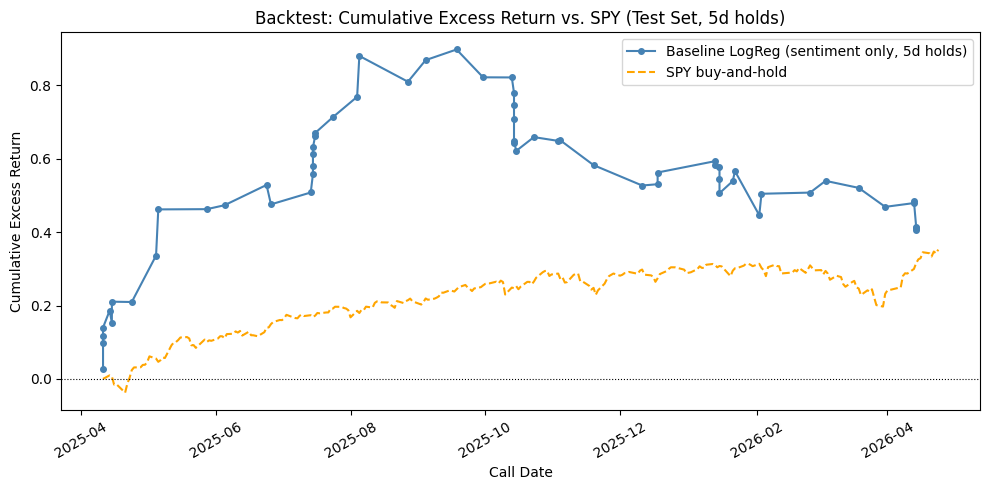

Saved to backtest_equity_curve.png


In [118]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Baseline signal PnL ---
test_plot = test.dropna(subset=[RET_COL]).copy()
test_plot = test_plot.sort_values('call_date').reset_index(drop=True)
test_plot['signal'] = baseline_signal(test_plot)
test_plot['pnl'] = test_plot['signal'] * test_plot[RET_COL]
test_plot['cum_pnl'] = test_plot['pnl'].cumsum()

# --- SPY buy-and-hold over same window ---
spy_prices = prices['SPY'].set_index('Date').sort_index()
t_start = test_plot['call_date'].min()
t_end   = test_plot['call_date'].max() + pd.Timedelta(days=30)
spy_window = spy_prices.loc[t_start:t_end, 'Close']
spy_bh = (spy_window / spy_window.iloc[0] - 1)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_plot['call_date'], test_plot['cum_pnl'],
        marker='o', markersize=4,
        label=f'Baseline LogReg (sentiment only, {HORIZON}d holds)', color='steelblue')
ax.plot(spy_bh.index, spy_bh.values,
        label='SPY buy-and-hold', color='orange', linewidth=1.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.set_title(f'Backtest: Cumulative Excess Return vs. SPY (Test Set, {HORIZON}d holds)')
ax.set_xlabel('Call Date')
ax.set_ylabel('Cumulative Excess Return')
ax.legend()
fig.tight_layout()
plt.savefig('backtest_equity_curve.png', dpi=150)
plt.show()
print('Saved to backtest_equity_curve.png')


## 9. Better Model — 6-Feature Logistic Regression (Task 3)

Logistic regression (C=0.1, standardised features) trained on the 6-feature base set to predict `sign(fwd_excess_5d)`.

**`FEATS_6`:** `sentiment`, `guidance_score`, `sentiment_delta`, `n_risks_delta`, `n_wins_delta`, `risk_persistence`

Compared to the §8 single-feature baseline, this adds guidance and QoQ momentum signals. Both direct and contrarian versions are reported — at the 5d horizon the initial post-earnings reaction is still intact, so the direction of any edge is an empirical question.

Note: `lm_sentiment` and `lm_sentiment_delta` are not included in `FEATS_6` to preserve backward comparability. They are evaluated in §10.


In [119]:
FEATS_6 = ['sentiment', 'guidance_score', 'sentiment_delta',
           'n_risks_delta', 'n_wins_delta', 'risk_persistence']

# --- Fit 6-feature LogReg on training set ---
X_tr, y_tr, d_tr = make_xy(train, feats=FEATS_6)
X_te, y_te, d_te = make_xy(test,  feats=FEATS_6)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

lr = LogisticRegression(C=0.1, max_iter=500, random_state=42)
lr.fit(X_tr_s, y_tr)

lr_signal     = pd.Series(lr.predict(X_te_s).astype(float), index=d_te.index)
contra_signal = -lr_signal

# --- Backtest comparison table ---
results = {
    f'Baseline (1-feat, {HORIZON}d)': backtest(d_te_b, baseline_signal(d_te_b)),
    f'LogReg 6-feat ({HORIZON}d)':    backtest(d_te,   lr_signal),
    f'Contrarian LR ({HORIZON}d)':    backtest(d_te,   contra_signal),
}

print(f'=== Backtest Results — {HORIZON}d horizon ===')
print(f"{'Model':<30} {'n':>4} {'Hit%':>6} {'IC':>8} {'Sharpe':>8}")
print('-' * 62)
for name, r in results.items():
    ic_str = f"{r['rank_IC']:+.3f}" if r['rank_IC'] == r['rank_IC'] else '   NaN'
    print(f"{name:<30} {r['n']:>4} {r['hit_rate']*100:>5.1f}% {ic_str:>8} {r['naive_sharpe']:>+8.3f}")

print('\nLogReg coefficients (std-normalised):')
for feat, coef in sorted(zip(FEATS_6, lr.coef_[0]), key=lambda x: -abs(x[1])):
    print(f'  {feat:<22} {coef:+.3f}')

# Continuous contrarian probability — used for cross-sectional ranking in §11
pos_idx = int(np.where(lr.classes_ == 1.0)[0][0]) if 1.0 in lr.classes_ else 1
d_te = d_te.copy()
d_te['contra_proba'] = 1 - lr.predict_proba(X_te_s)[:, pos_idx]


=== Backtest Results — 5d horizon ===
Model                             n   Hit%       IC   Sharpe
--------------------------------------------------------------
Baseline (1-feat, 5d)            60  60.0%   +0.007   +0.988
LogReg 6-feat (5d)               60  56.7%   -0.002   +0.925
Contrarian LR (5d)               60  43.3%   +0.002   -0.925

LogReg coefficients (std-normalised):
  sentiment_delta        +0.263
  guidance_score         -0.188
  n_wins_delta           -0.164
  sentiment              +0.146
  n_risks_delta          -0.053
  risk_persistence       +0.045


## 10. Enhanced Model — 9-Feature LogReg

Adds `theme_novelty`, `sector_rel_sentiment`, `aq_ratio` to the 6-feature base (`FEATS_9`).
Also reports individual ICs for `lm_sentiment` and `lm_sentiment_delta` — the LM features are available
here but left out of the primary model to keep `FEATS_9` comparable to the write-up.
To test an 11-feature model including LM features, extend `FEATS_9` with `['lm_sentiment', 'lm_sentiment_delta']`.

With only 70 training rows, the 9-feature model may underperform the 6-feature version — each additional
low-IC feature adds noise to the decision boundary at this sample size.


In [120]:
# ── Individual ICs for the three new features ─────────────────────────────────
print(f"=== New Feature ICs ({HORIZON}d horizon, test set) ===")
for feat in ['theme_novelty', 'sector_rel_sentiment', 'aq_ratio']:
    sub = test.dropna(subset=[feat, RET_COL])
    if len(sub) < 10:
        print(f"  {feat:<26} n too small"); continue
    ic = sub[[feat, RET_COL]].corr(method='spearman').iloc[0, 1]
    print(f"  {feat:<26} IC={ic:+.3f}  n={len(sub)}")

# ── Enhanced 9-feature LogReg ──────────────────────────────────────────────────
FEATS_9 = FEATS_6 + ['theme_novelty', 'sector_rel_sentiment', 'aq_ratio']

X_tr9, y_tr9, d_tr9 = make_xy(train, feats=FEATS_9)
X_te9, y_te9, d_te9 = make_xy(test,  feats=FEATS_9)

scaler9 = StandardScaler()
X_tr9_s = scaler9.fit_transform(X_tr9)
X_te9_s = scaler9.transform(X_te9)

lr9 = LogisticRegression(C=0.1, max_iter=500, random_state=42)
lr9.fit(X_tr9_s, y_tr9)

lr9_signal    = pd.Series(lr9.predict(X_te9_s).astype(float), index=d_te9.index)
contra9_signal = -lr9_signal

r_lr6 = backtest(d_te,  contra_signal)
r_lr9 = backtest(d_te9, contra9_signal)

print(f"\n=== Baseline vs Contrarian 6-feat vs Contrarian 9-feat ({HORIZON}d) ===")
print(f"{'Model':<26} {'n':>4} {'Hit%':>6} {'IC':>8} {'Sharpe':>8} {'W/L':>6}")
print('-' * 62)
for name, r in [('Baseline (1-feat)', r_base), ('Contrarian 6-feat', r_lr6), ('Contrarian 9-feat', r_lr9)]:
    ic_s = f"{r['rank_IC']:+.3f}" if r['rank_IC'] == r['rank_IC'] else '   NaN'
    wl_s = f"{r['win_loss_ratio']:.2f}" if r['win_loss_ratio'] == r['win_loss_ratio'] else '  NaN'
    print(f"{name:<26} {r['n']:>4} {r['hit_rate']*100:>5.1f}% {ic_s:>8} {r['naive_sharpe']:>+8.3f} {wl_s:>6}")

print("\nEnhanced LogReg coefficients (std-normalised):")
for feat, coef in sorted(zip(FEATS_9, lr9.coef_[0]), key=lambda x: -abs(x[1])):
    print(f"  {feat:<26} {coef:+.3f}")

print(f"\n=== Sector-relative sentiment (first 14 rows) ===")
print(features[['ticker', 'quarter', 'sentiment', 'sector', 'sector_rel_sentiment']].head(14).to_string())


=== New Feature ICs (5d horizon, test set) ===
  theme_novelty              IC=+0.256  n=60
  sector_rel_sentiment       IC=+0.184  n=60
  aq_ratio                   IC=-0.220  n=57

=== Baseline vs Contrarian 6-feat vs Contrarian 9-feat (5d) ===
Model                         n   Hit%       IC   Sharpe    W/L
--------------------------------------------------------------
Baseline (1-feat)            60  60.0%   +0.007   +0.988   0.96
Contrarian 6-feat            60  43.3%   +0.002   -0.925   0.93
Contrarian 9-feat            57  52.6%   +0.116   +0.098   0.93

Enhanced LogReg coefficients (std-normalised):
  sentiment_delta            +0.263
  theme_novelty              +0.256
  guidance_score             -0.214
  n_wins_delta               -0.170
  sentiment                  +0.141
  sector_rel_sentiment       +0.069
  aq_ratio                   -0.036
  n_risks_delta              -0.025
  risk_persistence           -0.011

=== Sector-relative sentiment (first 14 rows) ===
   ticker  

## 11. Extra Credit — Cross-Sectional Long-Short Portfolio

Ranks all tickers each quarter by the contrarian LR probability score (`contra_proba` from §9).
Longs the top 3, shorts the bottom 3, equal-weighted, 5-day hold at T+1 close.

Only quarters with ≥ 6 tickers reporting are included (ensures both sides have 3 names).
This structure removes market beta — returns reflect cross-sectional stock selection, not overall market direction.


=== Cross-Sectional Long-Short (5d) ===
  Q1-2025     L/S=-2.7%  long=['WFC', 'JPM', 'FAST']  short=['C', 'BLK', 'AMD']
  Q1-2026     L/S=+4.1%  long=['JPM', 'FAST', 'AVGO']  short=['GS', 'BLK', 'NKE']
  Q2-2025     L/S=+0.5%  long=['BLK', 'AMD', 'INTC']  short=['WFC', 'GS', 'FAST']
  Q3-2025     L/S=-1.5%  long=['C', 'GS', 'FAST']  short=['JNJ', 'INTC', 'BLK']
  Q4-2025     L/S=+2.6%  long=['NKE', 'JPM', 'C']  short=['AMD', 'FDX', 'PLTR']

Mean quarterly L/S return : 0.61%
Hit rate (quarters > 0)   : 60%
Annualised Sharpe (4 obs/yr): 0.43


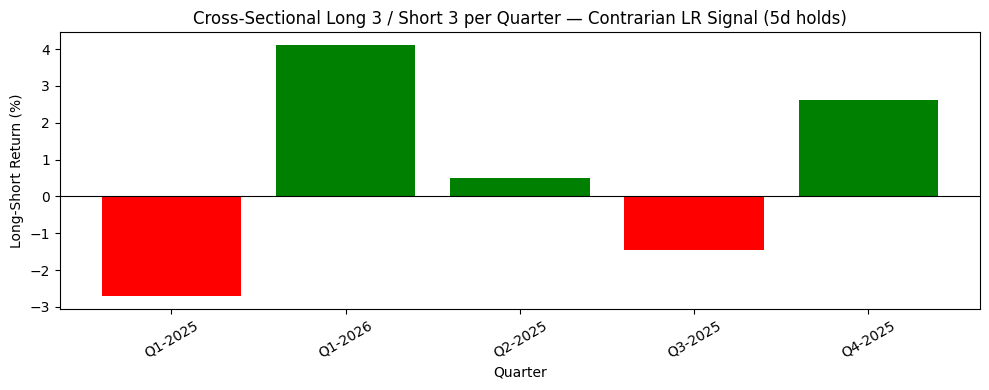

Saved to ls_portfolio.png


In [121]:
# Rank all tickers each quarter by contrarian probability; long top-3, short bottom-3.
ls_rows = []
for quarter, grp in d_te.dropna(subset=[RET_COL]).groupby('quarter'):
    if len(grp) < 6:
        continue
    grp = grp.sort_values('contra_proba', ascending=False).reset_index(drop=True)
    longs  = grp.head(3)
    shorts = grp.tail(3)
    ls_ret = longs[RET_COL].mean() - shorts[RET_COL].mean()
    ls_rows.append({
        'quarter': quarter,
        'ls_return': ls_ret,
        'longs':  list(longs['ticker']),
        'shorts': list(shorts['ticker']),
    })

ls_df = pd.DataFrame(ls_rows).sort_values('quarter').reset_index(drop=True)

print(f"=== Cross-Sectional Long-Short ({HORIZON}d) ===")
for _, row in ls_df.iterrows():
    sign = '+' if row['ls_return'] > 0 else ''
    print(f"  {row['quarter']:10}  L/S={sign}{row['ls_return']*100:.1f}%"
          f"  long={row['longs']}  short={row['shorts']}")

print(f"\nMean quarterly L/S return : {ls_df['ls_return'].mean()*100:.2f}%")
print(f"Hit rate (quarters > 0)   : {(ls_df['ls_return'] > 0).mean()*100:.0f}%")
ann_sharpe = ls_df['ls_return'].mean() / (ls_df['ls_return'].std() + 1e-9) * np.sqrt(4)
print(f"Annualised Sharpe (4 obs/yr): {ann_sharpe:.2f}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if r > 0 else 'red' for r in ls_df['ls_return']]
ax.bar(ls_df['quarter'], ls_df['ls_return'] * 100, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Quarter')
ax.set_ylabel('Long-Short Return (%)')
ax.set_title(f'Cross-Sectional Long 3 / Short 3 per Quarter — Contrarian LR Signal ({HORIZON}d holds)')
plt.xticks(rotation=30)
fig.tight_layout()
plt.savefig('ls_portfolio.png', dpi=150)
plt.show()
print('Saved to ls_portfolio.png')
